In [1]:
"""
File: spam_tuner_tng_targets.py
Author: Matthew Ogden
Email: ogdenm12@gmail.com
Github: mbogden
Created: 2024-Nov-12

Description: I discovered during the TNG to SPAM unit conversion process
    that the default SPAM hyperparameters were not optimal.  This script
    will tune the SPAM hyperparameters so they are able to produce SPAM orbits
    that are similar to the TNG orbits.  We hypothesize that if the SPAM orbits 
    match the TNG orbits, then the tidal features SPAM is able to produce will 
    more accurately resemble and recreate the TNG tidal features.

References: 
- Sections of this code were written with the assistance of ChatGPT made by OpenAI.
- TNG50 Simulation Data
    - Nelson, D. et al. (2015). The Illustris Simulation: Public Data Release. Astronomy and Computing, 13, 12–37. https://doi.org/10.1016/j.ascom.2015.09.003
    - Nelson, D. et al. (2019). First results from the TNG50 simulation: Galactic outflows driven by supernovae and black hole feedback. Monthly Notices of the Royal Astronomical Society, 490(3), 3234–3261. https://doi.org/10.1093/mnras/stz2306
    - Pillepich, A. et al. (2019). First results from the TNG50 simulation: The evolution of stellar and gaseous discs across cosmic time. Monthly Notices of the Royal Astronomical Society, 490(3), 3196–3233. https://doi.org/10.1093/mnras/stz2338

"""
# ================================ IMPORTS ================================ #
import os, sys, logging, time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpi4py import MPI

# Add main project directory to import project modules
try:
    SCRIPT_DIRECTORY = os.path.dirname(os.path.realpath(__file__))
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    sys.path.append(PROJECT_DIRECTORY)

except:
    # Assume we are running from the script directory
    SCRIPT_DIRECTORY = os.getcwd()
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    
    # Also assume you might be in galStuff directory
    work_dir = os.getcwd()
    if 'galStuff' == work_dir.split('/')[-1]:
        PROJECT_DIRECTORY =  work_dir + '/galaxyJSPAM'
        sys.path.append(PROJECT_DIRECTORY)

# Import project modules
import IllustrisTNG.tng_functions as tf
import IllustrisTNG.convert_tng_to_spam as cts
import utilities.parallel_queue_manager as qm
# import Optimization_Methods.optimization_manager as om
import Simulator.new_simulator as sim
import utilities.general_utility as gu

# ================================ GLOBALS ================================ #
# Global logger from main program
script_args, LOGGER = gu.initialize_environment()
logger = LOGGER
buildEnv = True # Makefile will change this to False in script

# # If buildEnv is True, then we can assume we're in a jupyter notebook
if buildEnv:
    logger.setLevel(logging.DEBUG)
    np.set_printoptions(precision=2)
    from importlib import reload

# Set NumPy print options to reduce the precision to 3 decimal places
logger.debug("Imports Done")

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-1c713quc because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Time:2024-12-20 09:40:40,576 - [976392498.<module>] - DEBUG - Imports Done


# TNG Sample Targets
Let's load a few targets and example orbits that we'll want to score.  

Time:2024-12-20 09:40:42,336 - [new_simulator.spam_orbit] - INFO - Running SPAM Simulation - Orbit Run
Time:2024-12-20 09:40:42,338 - [new_simulator.set_spam_parameters] - INFO - Setting SPAM Parameters: 


Simulating Orbit: Default


Time:2024-12-20 09:40:45,816 - [new_simulator.spam_orbit] - INFO - Running SPAM Simulation - Orbit Run
Time:2024-12-20 09:40:45,818 - [new_simulator.set_spam_parameters] - INFO - Setting SPAM Parameters: 


Simulating Orbit: Hand Found


Time:2024-12-20 09:40:50,162 - [new_simulator.spam_orbit] - INFO - Running SPAM Simulation - Orbit Run
Time:2024-12-20 09:40:50,163 - [new_simulator.set_spam_parameters] - INFO - Setting SPAM Parameters: 


Simulating Orbit: Off Time


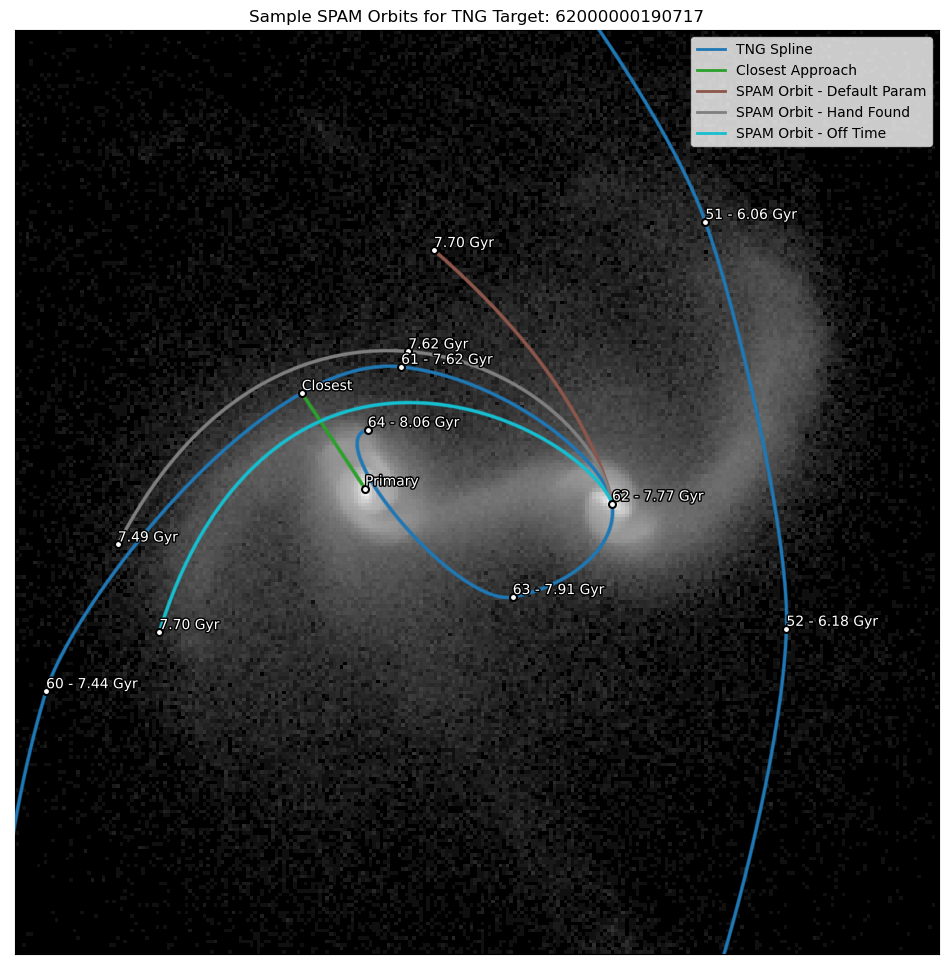

In [2]:
if buildEnv:
     # Set logger level
    logger.setLevel(logging.INFO)

    # Target IDs
    p1 = 62000000190717 

    # Load the TNG orbits
    tng_target_1 = cts.get_tng_target_orbit( p1, dev_print = False, use_spline='hermite' )
    
    # Load TNG Particles
    if tng_target_1.get('pts') is None:
        tng_target_1['pts'] = cts.get_tng_target_pts( tng_target_1['current_info'], dev_print = False )
    
    # Create container for spam parameters and orbits of interest
    tng_target_1['test_orbits'] = {}
    tng_target_1['test_orbits']['Default'] = {}
    tng_target_1['test_orbits']['Hand Found'] = { 'm_halo': 6.4, 'lnl': 0.007, 'r_scale': 20 }
    tng_target_1['test_orbits']['Off Time'] = { 'm_halo': 9, 'lnl': 0.04, 'r_scale': 6 }
    
    # Add Default SPAM Parameters
    print( f"Simulating Orbit: Default" )
    tng_target_1['test_orbits']['Default']['orbit'] = sim.spam_orbit( tng_target_1['spam_ar_v2'], current_time=tng_target_1['current_time'], spam_setup_params={} )
    _ = cts.add_spam_orbit_info( tng_target_1['test_orbits']['Default']['orbit'], tng_target_1, f'SPAM Orbit - Default Param', True, False )

    print( f"Simulating Orbit: Hand Found" )
    tng_target_1['test_orbits']['Hand Found']['orbit'] = sim.spam_orbit( tng_target_1['spam_ar_v2'], current_time=tng_target_1['current_time'], spam_setup_params=tng_target_1['test_orbits']['Hand Found'] )
    _  = cts.add_spam_orbit_info( tng_target_1['test_orbits']['Hand Found']['orbit'], tng_target_1, f'SPAM Orbit - Hand Found', True, False, )

    print( f"Simulating Orbit: Off Time" )
    tng_target_1['test_orbits']['Off Time']['orbit'] = sim.spam_orbit( tng_target_1['spam_ar_v2'], current_time=tng_target_1['current_time'], spam_setup_params=tng_target_1['test_orbits']['Off Time'] )
    _ = cts.add_spam_orbit_info( tng_target_1['test_orbits']['Off Time']['orbit'], tng_target_1, f'SPAM Orbit - Off Time', True, False,  )
    
    tf.xy_histogram(
        hist_data=tng_target_1['pts'],
        plot_data=tng_target_1['plot_list'], plot_labels=tng_target_1['plot_labels'],
        annotations=tng_target_1['annotations'], 
        title=f"Sample SPAM Orbits for TNG Target: {p1}",
        figsize=(12,12),
    )


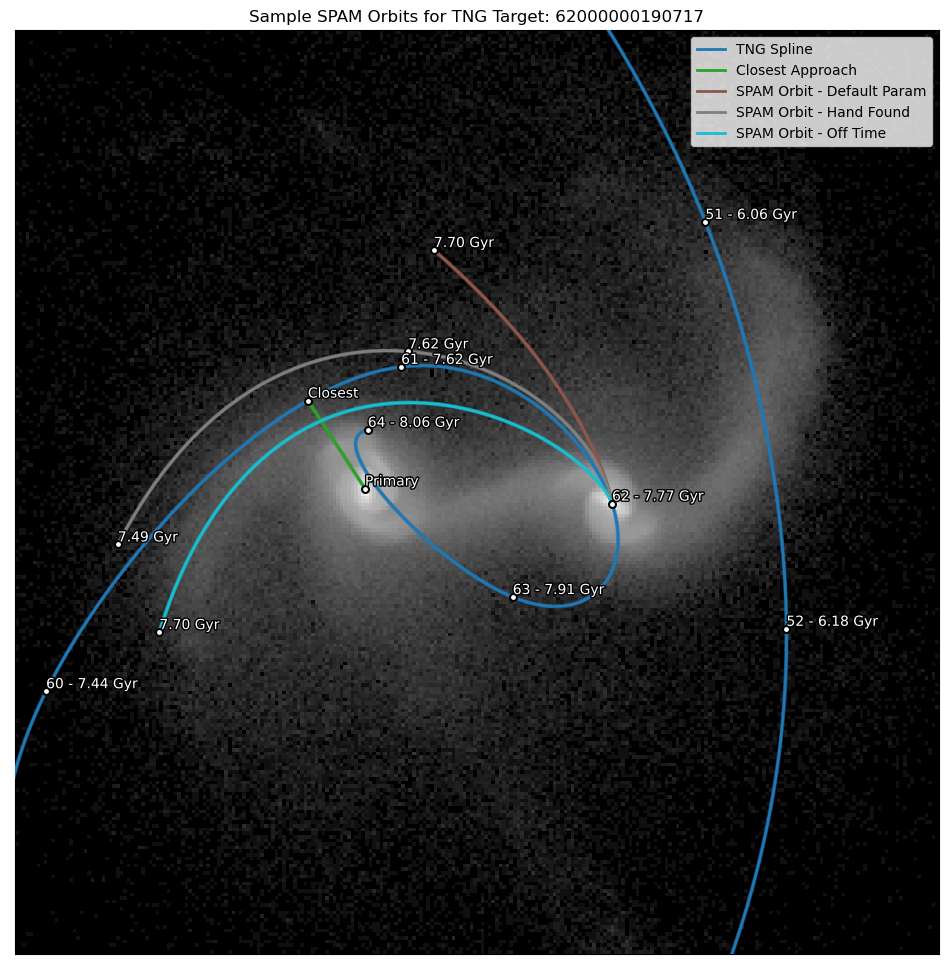

---
---
# Orbit Similarity Function
## Inital Problems
While trying a few simple fitness function's for comparing the TNG and SPAM simulation, I came across 2 primary issues:

1) The SPAM simulation ends early if galaxies are not likely to merge.  This is to preserve computational resources for other SPAM runs. 
2) The SPAM and TNG starting parameters are identical (since they use the same starting parameters).  Thus SPAM runs that end early, have orbit paths that are very close to TNG. 

## Solution
Accordinging to literature, the tidal features of merging galaxies are highly influenced by the moment of closest approach (when the two galaxies are closest), because that is when tidal forces are highest.  Therefore, I decided to implement two aspects to the orbit similarity fitness function that keeps this in mind. 

2) **Fixed Time Frame** - Calculate a fixed time frame centered around the moment of closest approach in TNG.  If the SPAM orbit ends early (fails to simulate far enough back in time) it will be punished.
1) **Weighted Fitness Function** - Give more importance to the weight function centered on the moment of closest approach.  Have weights drop the further you are from this point.   


NOTE: A cautious about wording orbit times within SPAM simulation.  The SPAM simulation takes collision parameters for the **current** moment (what we observe) and simulates an orbit of the galaxies *backwards* in time.   Thus, the start of the orbit simuation is **fixed** at the final position and time, and integrates backwards to earlier times/positions of the orbit.  Making the end of the simulation the **starting** time.  I make this note it has caused some confusion while coding and explaining to others. 

---
---



### Weighted Fitness Function

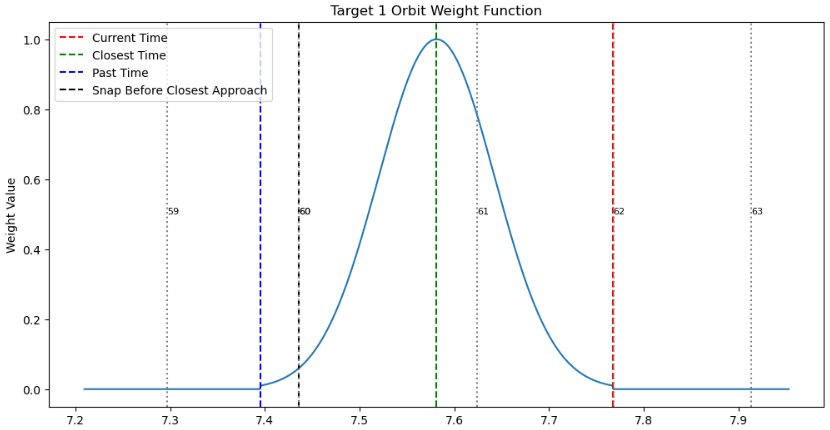

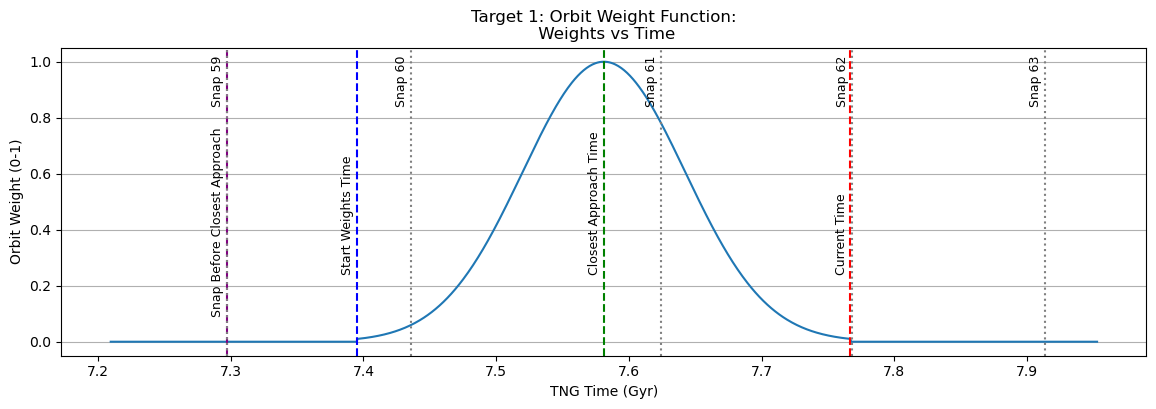

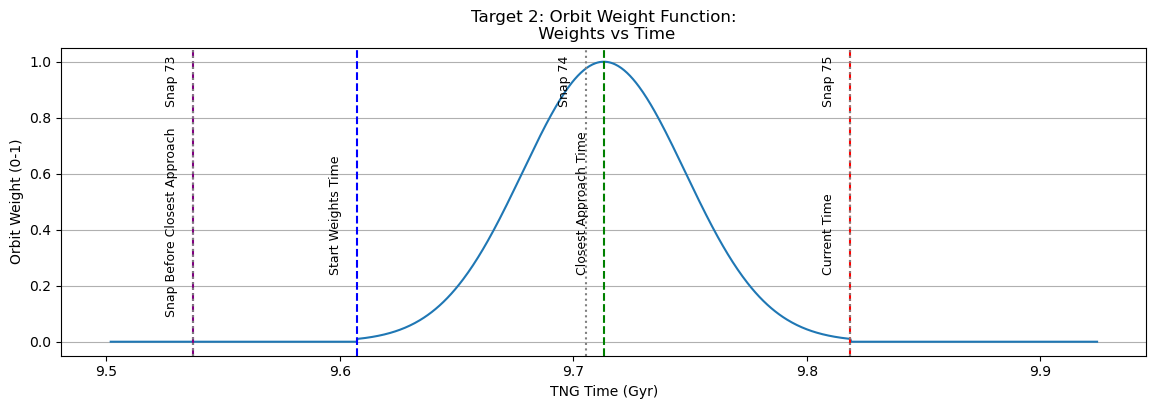

<Figure size 640x480 with 0 Axes>

In [3]:
def gen_orbit_weight_func_of_closest_approach( tng_orbit, boundary_value = 0.01, scale_past = 1.0 ):
    """
    Generate weight related variables and a gaussian function centered on the moment of closest approach.
    Meant to weigh a fitness function comparing TNG and SPAM orbits.
    The weighting function will be zero outside of the past and current times of the orbit.

    path: dict - Accumlated orbit path information for a particular TNG target
    weight_boundary: float (0,1) - The value of the weighting function at current time.
    scale_past: float (Defualt 1.0) - Scale the weighting function for times before the closest approach.
    """

    # Build dictionary to contain variables and weight function
    tng_orbit['orbit_weight'] = {}

    # Store useful variables for later
    tng_orbit['orbit_weight']['boundary_value'] = boundary_value
    tng_orbit['orbit_weight']['scale_past'] = scale_past
    tng_orbit['orbit_weight']['delta_time'] = tng_orbit['current_time'] - tng_orbit['closest_time']   # Time difference between closest and current time
    tng_orbit['orbit_weight']['start_time'] = tng_orbit['closest_time'] - tng_orbit['orbit_weight']['delta_time'] * scale_past

    # Weight function variables
    start_time = tng_orbit['orbit_weight']['start_time']
    closest_time = tng_orbit['closest_time']
    current_time = tng_orbit['current_time']
    gaussian_weight_after = - ( tng_orbit['orbit_weight']['delta_time']**2 / (2 * np.log( boundary_value ) ) )
    gaussian_weight_before = - ( (scale_past*tng_orbit['orbit_weight']['delta_time'])**2 / (2 * np.log( boundary_value ) ) )

    def weight_func( time ):
        """
        Generate the weight for a given time
        """

        # If a list or array, recursively apply the function to each element
        if isinstance(time, list) or isinstance(time, np.ndarray):
            return np.array([ weight_func( t ) for t in time ])

        # If outside of weight range, return 0
        if time < start_time:    return 0
        elif time > current_time:    return 0

        # between closest and current time
        elif time > closest_time:    
            return np.exp( -( (time - closest_time)**2 / (2*gaussian_weight_after) ) )

        # else between start and closest time
        else:    
            return np.exp( -( (time - closest_time)**2 / (2*gaussian_weight_before) ) )
    
    tng_orbit['orbit_weight']['function'] = weight_func
    

def plot_weight_function( tng_target, title = "Orbit Weight Function" ):
    """
    Plot the weight function for the given path
    """

    # Generate test times
    plot_start = tng_target['past_time']-tng_target['orbit_weight']['delta_time']
    plot_end = tng_target['current_time']+tng_target['orbit_weight']['delta_time']
    plot_times_su = np.linspace( plot_start, plot_end, 1000 )
    plot_weights = tng_target['orbit_weight']['function']( plot_times_su )
    plot_times_tng = cts.convert_time_spam_to_tng( plot_times_su )

    plt.clf()
    plt.plot( plot_times_tng, plot_weights )

    plt.title(title)
    plt.xlabel("TNG Time (Gyr)")
    plt.ylabel("Orbit Weight (0-1)")

    #
    t_off = -0.012
    t_font = 9

    # Add vertical dash lines for current, past, and closest times
    c_val = cts.convert_time_spam_to_tng( tng_target['current_time'])
    plt.axvline( c_val, color='r', linestyle='--', label='Current Time' )
    plt.text( c_val+t_off, 0.25, f"Current Time", rotation=90, fontsize=t_font, )

    t_val = cts.convert_time_spam_to_tng( tng_target['closest_time'] )
    plt.axvline( t_val, color='g', linestyle='--', label='Closest Time' )
    plt.text( t_val+t_off, 0.25, f"Closest Approach Time", rotation=90, fontsize=t_font, )

    p_val = cts.convert_time_spam_to_tng( tng_target['past_time'] )
    plt.axvline( p_val, color='b', linestyle='--', label='Weight Start Time' )
    plt.text( p_val+t_off, 0.25, f"Start Weights Time", rotation=90, fontsize=t_font, )

    # Show time of snap before closest approach
    sb_val = cts.convert_time_spam_to_tng( tng_target['snap_before_closest_approach_time'] )
    plt.axvline( sb_val, color='purple', linestyle='--', label='Snap Before Closest Approach' )
    plt.text( sb_val+t_off, 0.1, f"Snap Before Closest Approach", rotation=90, fontsize=t_font, )
    
    # Add snap times and lines to plot
    snap_list = []

    for i in range(len(tng_target['snaps'])):

        # If between plot time, add to plot
        if tng_target['times_su'][i] > plot_start and tng_target['times_su'][i] < plot_end:
            # snap_list.append(tng_target['snaps'][i] )
            s_val = cts.convert_time_spam_to_tng( tng_target['times_su'][i] )
            plt.axvline( s_val, color='grey', linestyle=':', )
            plt.text( s_val+t_off, 0.85, f"Snap {tng_target['snaps'][i]}", rotation=90, fontsize=t_font )

    # Make plot bigger
    plt.gcf().set_size_inches(14, 4)

    # Add only horizontal gridlines
    plt.grid(axis='y')

    # # Legend
    # plt.legend()
    plt.show()
    plt.clf()
    
# end function
    
if buildEnv:
    logger.setLevel(logging.INFO)

    gen_orbit_weight_func_of_closest_approach(tng_target_1, boundary_value = 0.01, )
    plot_weight_function( tng_target_1, title="Target 1: Orbit Weight Function:\n Weights vs Time" )

    p2 = 75000000121160
    tng_target_2 = cts.get_tng_target_orbit( p2, dev_print = False, use_spline='hermite' )
    gen_orbit_weight_func_of_closest_approach(tng_target_2, boundary_value = 0.01, )
    plot_weight_function( tng_target_2, title="Target 2: Orbit Weight Function:\n Weights vs Time" )


    

## Weighted Orbit Similarity Fitness Function

Here is the basis for this function.

1) Sets a fixed time frame to score, based on spline of TNG orbit centered around the moment of closest approach.  
1) It takes the time steps from the SPAM orbit.  If shorter than fixed time frame, it extends to the timesteps to the full time.
1) Those timesteps are used to generate weight values and positions from the TNG orbit spline.  
1) Iterates over each time step, calculating the distance squared between orbit positions.  
1) If SPAM does not go fully back in time, the function iterates over the remaining TNG orbit and computes the difference between it and the starting SPAM position.
1) Weights are applied to the errors, and normalized so it's the average weighted error.  


Score for Orbit: Default - 4.06649


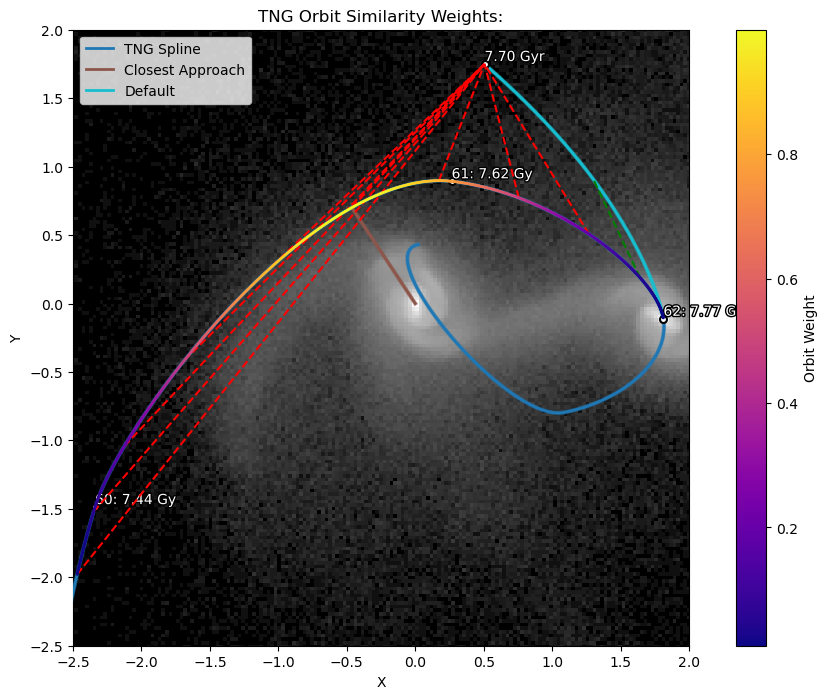

Score for Orbit: Hand Found - 0.08758


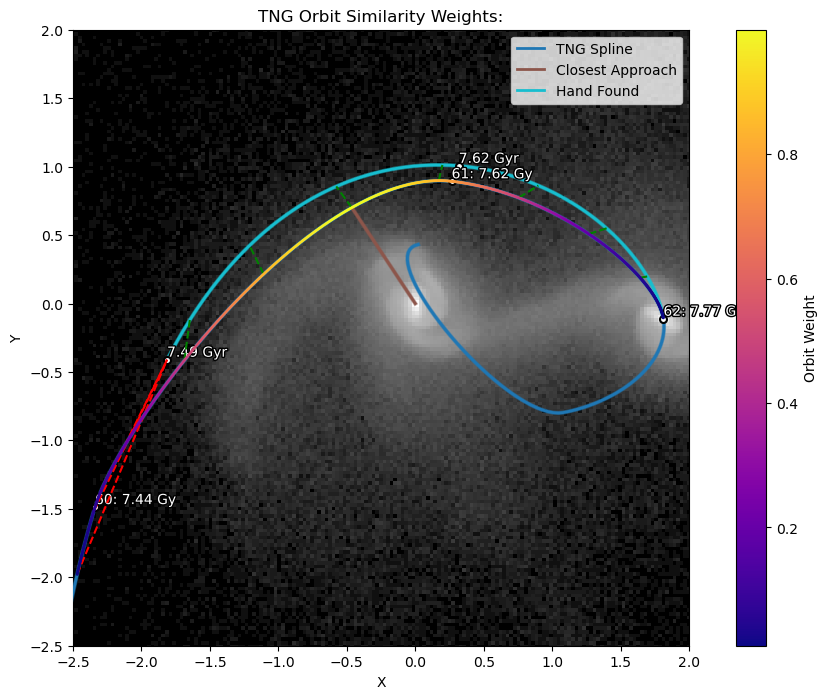

Score for Orbit: Off Time - 4.36375


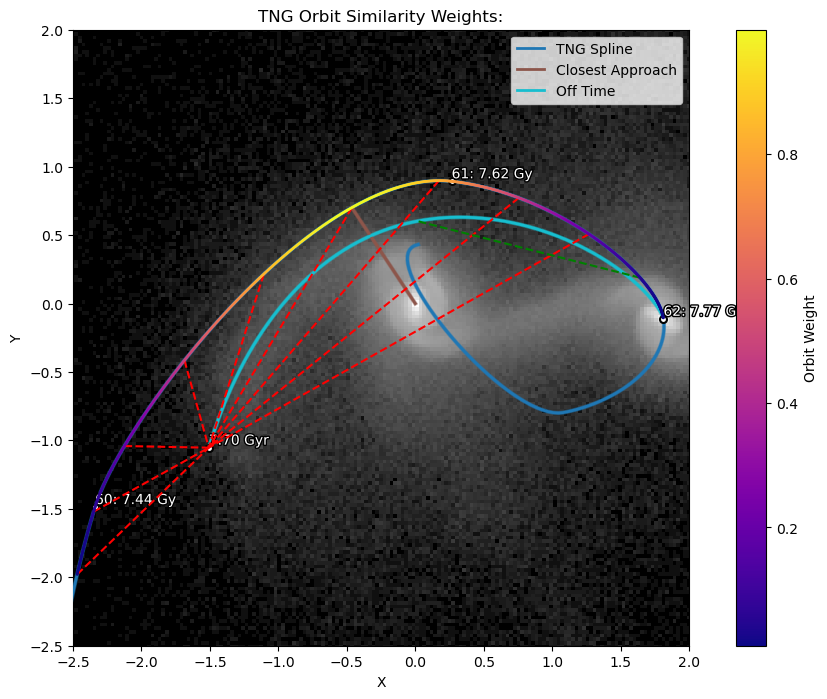

In [4]:
def score_function_orbit_similarity_over_time( spam_orbit, tng_target ):

    LOGGER.debug("Score Function for Orbit Similarity")

    # Get info from SPAM orbit
    n_spam = len(spam_orbit)  # length of spam run
    spam_times = spam_orbit[:,-1]  # Times in spam run

    LOGGER.debug("SPAM Orbit: %s", spam_orbit.shape)
    LOGGER.debug( f"SPAM Time: {spam_times[0]:.2f} - {spam_times[-1]:.2f} Gyr")

    # If spam run ends before the past time, add more time steps
    if spam_times[0] > tng_target['past_time']:
        LOGGER.debug("SPAM run ended before reaching past time")

        # Get number of time steps needed to fill the gap between spam_time[0] and tng_target['past_time']
        spam_dt = abs((spam_times[-1] - spam_times[0]) / (n_spam - 1))
        n_more = int( np.ceil( (spam_times[0] - tng_target['past_time']) / spam_dt ) )
        LOGGER.debug( f"Adding {n_more} more time steps to SPAM run")

        # Log previous time steps
        LOGGER.debug( f"SPAM Times: {spam_times.shape}")
        LOGGER.debug( f"{spam_times[:3]} - {spam_times[-3:]}")

        # Create new time array that goes back to the past time
        new_times = np.linspace( tng_target['past_time'], spam_times[0], n_more )        
        LOGGER.debug( f"New Times: {new_times.shape}")
        LOGGER.debug( f"{new_times[:3]} - {new_times[-3:]}")
        
        times = np.concatenate( (new_times, spam_times) )

    # Else use the spam run times
    else:
        n_more = 0
        times = spam_times

    # Log previous time steps
    LOGGER.debug( f"Comparing Times: {times.shape}")
    LOGGER.debug( f"{times[:3]} - {times[-3:]}")

    # Create tng_orbit from spline and times
    n = len(times)  # length of times array
    tng_orbit = tng_target['generate_spline']( times )
    LOGGER.debug( f"TNG Orbit Spline: {tng_orbit.shape}")
    
    # Create weights from tng_orbit
    weights = tng_target['orbit_weight']['function']( times )
    LOGGER.debug( f"Weights: {weights.shape}")

    # Loop through orbits and compute errors
    errors = np.zeros(n)
    for i in range(n):

        # If i is less than n_more, use the first simulated position
        if i < n_more:
            e = np.linalg.norm(spam_orbit[0,0:3] - tng_orbit[i,0:3]) ** 2
        
        # Else compare orbits at the same time step
        else:
            spam_idx = i - n_more
            e = np.linalg.norm(spam_orbit[spam_idx,0:3] - tng_orbit[i,0:3]) ** 2

        errors[i] = e

    LOGGER.debug( f"Errors: {errors.shape}")

    # Calcule normalization factor for normalized weighted error
    total_weight = np.sum(weights)
    E = np.sum(weights * errors)
    E_normalized = E / total_weight

    LOGGER.debug( f"Weighted Error: {E_normalized}")

    return E_normalized


def plot_weights_and_error_over_time( tng_target, spam_orbit, orbit_name = 'SPAM Orbit', title = "Orbit Similarity Function" ):

    tng_target['reset_plot_info']()

    tmp_plot = tng_target['plot_list']
    tmp_plot_labels = tng_target['plot_labels']

    tmp_plot.append( spam_orbit )
    tmp_plot_labels.append( orbit_name )

    tmp_annotations = []

    # Add current position
    tmp_annotations.append(( spam_orbit[-1,0:2], f"{tng_target['current_snap']}: {cts.convert_time_spam_to_tng(tng_target['current_time']):.2f} Gy" ))

    # Append snaps only between past and current times, excluding current
    for i in range(len(tng_target['snaps'])):
        if tng_target['times_su'][i] >= tng_target['past_time'] and tng_target['times_su'][i] <= tng_target['current_time']:
            tmp_annotations.append(( tng_target['s_fixed_su'][i], f"{tng_target['snaps'][i]}: {tng_target['times'][i]:.2f} Gy" ))
        
    # Add spam orbit
    tmp_annotations, tmp_plot, tmp_plot_labels = cts.add_spam_orbit_info( spam_orbit, tng_target, orbit_name, False, False, tmp_annotations, tmp_plot, tmp_plot_labels )

    tf.xy_histogram( \
        tng_target['pts'], \
        tmp_plot, tmp_plot_labels, \
        show_labels = True, std_dev = 3,
        annotations= tmp_annotations,
        title = f"TNG Orbit Similarity Weights:",
        # ext_ax = axs[0],
        figsize=(10,10)
    )

    # Get times from spam orbit 
    spam_times = spam_orbit[:,-1]
    # if start time is after past time, calculate delta t and extend times array
    if spam_times[0] > tng_target['past_time']:
        n_more = int( np.ceil( (spam_times[0] - tng_target['past_time']) / abs(spam_times[1] - spam_times[0]) ) )
        new_times = np.linspace( tng_target['past_time'], spam_times[0], n_more )        
        times = np.concatenate( (new_times, spam_times) )
    else:
        times = spam_times

    # Create tng_orbit for those times
    tng_orbit = tng_target['generate_spline']( times )
    
    # Iterate over times to plot n differences
    n = 10
    for i in range( n ):
        idx = int(i * len(times) / n)
        pos_tng = tng_orbit[idx]
        if idx < n_more:
            pos_spam = spam_orbit[0]
            plt.plot( [pos_tng[0], pos_spam[0]], [pos_tng[1], pos_spam[1]], 'r--', zorder=10 )
        else:
            pos_spam = spam_orbit[idx-n_more]
            plt.plot( [pos_tng[0], pos_spam[0]], [pos_tng[1], pos_spam[1]], 'g--', zorder=10 )

    # Create positions from spline and times

    # Set sample times
    plot_start = tng_target['past_time']
    plot_end = tng_target['current_time']
    plot_times = np.linspace( plot_start, plot_end, 1000 )
    plot_weights = tng_target['orbit_weight']['function']( plot_times )
    
    pos_su = tng_target['generate_spline']( plot_times )
    # pos_tng = cts.convert_distance_tng_to_spam( pos_su )

    # Add weight values to plot
    # Ensure this scatter is on top of previous plots
    sc = plt.scatter( pos_su[:,0], pos_su[:,1], c=plot_weights, cmap='plasma', s=1, zorder=10 )
    plt.colorbar(sc, label='Orbit Weight')

    # Set plot size
    plt.gcf().set_size_inches(12, 8)

    # redifine limits
    plt.xlim(-2.5,2)
    plt.ylim(-2.5,2.0)

    plt.show()



if buildEnv:


    logger.setLevel(logging.INFO)

    tng_target_1['reset_plot_info']()

    # Get Limited Plot data
    spam_orbit = tng_target_1['test_orbits']['Default']['orbit']
    # Create container for spam parameters and orbits of interest
    # tng_target_1['test_orbits']['Hand Found'] = { 'm_halo': 6.4, 'lnl': 0.007, 'r_scale': 20 }
    # tng_target_1['test_orbits']['Off Time'] = { 'm_halo': 9, 'lnl': 0.04, 'r_scale': 6 }

    for key, orbit_info in tng_target_1['test_orbits'].items():
        spam_orbit = orbit_info['orbit']
        score = score_function_orbit_similarity_over_time( spam_orbit, tng_target_1 )
        print( f"Score for Orbit: {key} - {score:.5f}" )

        plot_weights_and_error_over_time( tng_target_1, spam_orbit, orbit_name = key, title=f"Orbit Similarity Function: {key}" )
        # break



Score for Orbit: Default - 4.06649


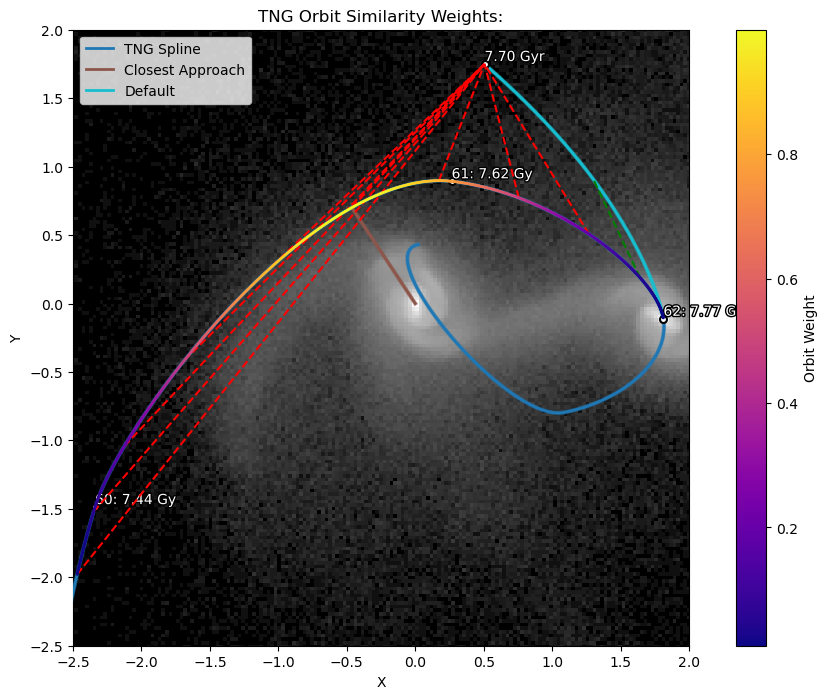

Score for Orbit: Hand Found - 0.08758


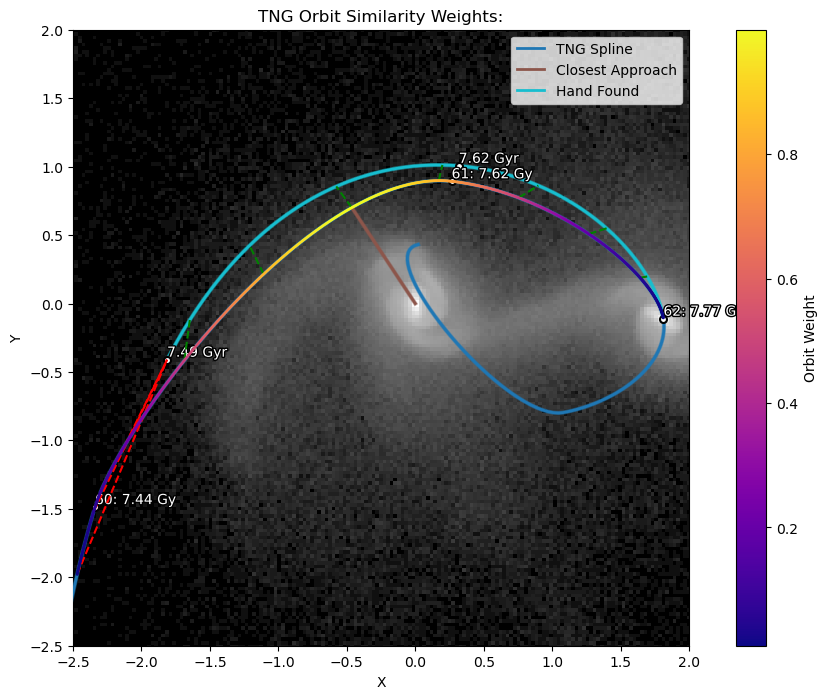

Score for Orbit: Off Time - 4.36375


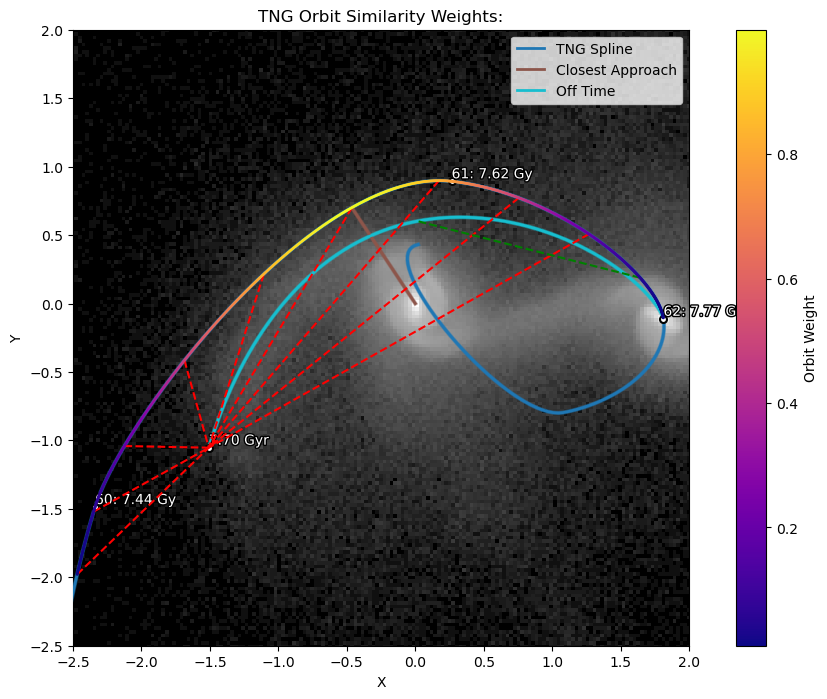

In [7]:
def score_function_orbit_similarity_over_pos( spam_orbit, tng_target ):
    """
    This function will compare the SPAM orbit to the TNG orbit based on position.  
    It will iterate over the TNG orbit and calculate the distance to the nearest SPAM orbit position.
    Also considers a weighting function that gives more weight to the closest approach time.

    inputs:
    spam_orbit: np.array [x,y,z,vx,vy,vz,t] - SPAM orbit positions, velocities, and times
    tng_target: dict - IllustrisTNG Target information

    """

    LOGGER.debug("Score Function for Orbit Similarity by Position")
    LOGGER.debug("SPAM Orbit: %s", spam_orbit.shape)

    # Since we've using the TNG orbit as a basis. 

    # Create tng_orbit from spline and times
    n = len(times)  # length of times array
    tng_orbit = tng_target['generate_spline']( times )
    LOGGER.debug( f"TNG Orbit Spline: {tng_orbit.shape}")
    
    # Create weights from tng_orbit
    weights = tng_target['orbit_weight']['function']( times )
    LOGGER.debug( f"Weights: {weights.shape}")

    # Loop through orbits and compute errors
    errors = np.zeros(n)
    for i in range(n):

        # If i is less than n_more, use the first simulated position
        if i < n_more:
            e = np.linalg.norm(spam_orbit[0,0:3] - tng_orbit[i,0:3]) ** 2
        
        # Else compare orbits at the same time step
        else:
            spam_idx = i - n_more
            e = np.linalg.norm(spam_orbit[spam_idx,0:3] - tng_orbit[i,0:3]) ** 2

        errors[i] = e

    LOGGER.debug( f"Errors: {errors.shape}")

    # Calcule normalization factor for normalized weighted error
    total_weight = np.sum(weights)
    E = np.sum(weights * errors)
    E_normalized = E / total_weight

    LOGGER.debug( f"Weighted Error: {E_normalized}")

    return E_normalized

def plot_weights_and_error_over_pos( tng_target, spam_orbit, orbit_name = 'SPAM Orbit', title = "Orbit Similarity Function" ):

    tng_target['reset_plot_info']()

    tmp_plot = tng_target['plot_list']
    tmp_plot_labels = tng_target['plot_labels']

    tmp_plot.append( spam_orbit )
    tmp_plot_labels.append( orbit_name )

    tmp_annotations = []

    # Add current position
    tmp_annotations.append(( spam_orbit[-1,0:2], f"{tng_target['current_snap']}: {cts.convert_time_spam_to_tng(tng_target['current_time']):.2f} Gy" ))

    # Append snaps only between past and current times, excluding current
    for i in range(len(tng_target['snaps'])):
        if tng_target['times_su'][i] >= tng_target['past_time'] and tng_target['times_su'][i] <= tng_target['current_time']:
            tmp_annotations.append(( tng_target['s_fixed_su'][i], f"{tng_target['snaps'][i]}: {tng_target['times'][i]:.2f} Gy" ))
        
    # Add spam orbit
    tmp_annotations, tmp_plot, tmp_plot_labels = cts.add_spam_orbit_info( spam_orbit, tng_target, orbit_name, False, False, tmp_annotations, tmp_plot, tmp_plot_labels )

    tf.xy_histogram( \
        tng_target['pts'], \
        tmp_plot, tmp_plot_labels, \
        show_labels = True, std_dev = 3,
        annotations= tmp_annotations,
        title = f"TNG Orbit Similarity Weights:",
        # ext_ax = axs[0],
        figsize=(10,10)
    )

    # Get times from spam orbit 
    spam_times = spam_orbit[:,-1]
    # if start time is after past time, calculate delta t and extend times array
    if spam_times[0] > tng_target['past_time']:
        n_more = int( np.ceil( (spam_times[0] - tng_target['past_time']) / abs(spam_times[1] - spam_times[0]) ) )
        new_times = np.linspace( tng_target['past_time'], spam_times[0], n_more )        
        times = np.concatenate( (new_times, spam_times) )
    else:
        times = spam_times

    # Create tng_orbit for those times
    tng_orbit = tng_target['generate_spline']( times )
    
    # Iterate over times to plot n differences
    n = 10
    for i in range( n ):
        idx = int(i * len(times) / n)
        pos_tng = tng_orbit[idx]
        if idx < n_more:
            pos_spam = spam_orbit[0]
            plt.plot( [pos_tng[0], pos_spam[0]], [pos_tng[1], pos_spam[1]], 'r--', zorder=10 )
        else:
            pos_spam = spam_orbit[idx-n_more]
            plt.plot( [pos_tng[0], pos_spam[0]], [pos_tng[1], pos_spam[1]], 'g--', zorder=10 )

    # Create positions from spline and times

    # Set sample times
    plot_start = tng_target['past_time']
    plot_end = tng_target['current_time']
    plot_times = np.linspace( plot_start, plot_end, 1000 )
    plot_weights = tng_target['orbit_weight']['function']( plot_times )
    
    pos_su = tng_target['generate_spline']( plot_times )
    # pos_tng = cts.convert_distance_tng_to_spam( pos_su )

    # Add weight values to plot
    # Ensure this scatter is on top of previous plots
    sc = plt.scatter( pos_su[:,0], pos_su[:,1], c=plot_weights, cmap='plasma', s=1, zorder=10 )
    plt.colorbar(sc, label='Orbit Weight')

    # Set plot size
    plt.gcf().set_size_inches(12, 8)

    # redifine limits
    plt.xlim(-2.5,2)
    plt.ylim(-2.5,2.0)

    plt.show()


    


if buildEnv:


    logger.setLevel(logging.INFO)

    tng_target_1['reset_plot_info']()

    # Get Limited Plot data
    spam_orbit = tng_target_1['test_orbits']['Default']['orbit']
    # Create container for spam parameters and orbits of interest
    # tng_target_1['test_orbits']['Hand Found'] = { 'm_halo': 6.4, 'lnl': 0.007, 'r_scale': 20 }
    # tng_target_1['test_orbits']['Off Time'] = { 'm_halo': 9, 'lnl': 0.04, 'r_scale': 6 }

    for key, orbit_info in tng_target_1['test_orbits'].items():
        spam_orbit = orbit_info['orbit']
        score = score_function_orbit_similarity_over_pos( spam_orbit, tng_target_1 )
        print( f"Score for Orbit: {key} - {score:.5f}" )

        # plot_weights_and_error_over_time( tng_target_1, spam_orbit, orbit_name = key, title=f"Orbit Similarity Function: {key}" )
        # break



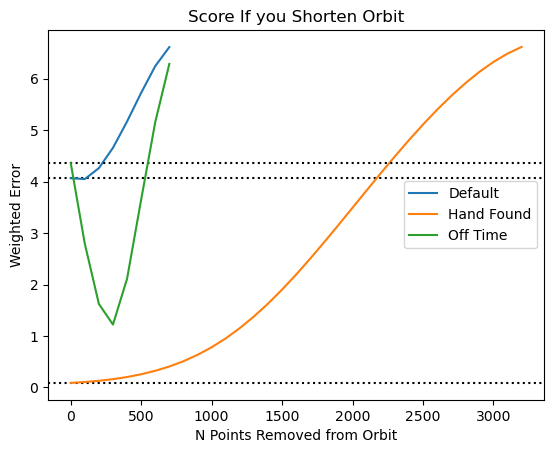

In [ ]:
if buildEnv:

    # I want to see how the score changes if I shorten the hand_orbit
    # one of the issues was the program overscored short orbits

    LOGGER.setLevel(logging.INFO)

    for label, orbit_info in tng_target_1['test_orbits'].items():
        orbit = orbit_info['orbit']
        n = len(orbit)
        scores = []
        lengths = []
        for i in range(0, n, 100):
            print(f"Scoring orbit length: {i} / {n}", end='\r')
            tmp_score = score_function_orbit_similarity( orbit[i:], tng_target_1 )

            # If i == 0, this is default score
            if i == 0:
                plt.axhline( tmp_score, color='k', linestyle=':' )

            scores.append( tmp_score )
            lengths.append( i )
        
        plt.plot( lengths, scores, label=label )


    plt.title("Score If you Shorten Orbit")
    plt.legend()

    plt.xlabel("N Points Removed from Orbit")
    plt.ylabel("Weighted Error")

    # Scale y axis
    # plt.yscale('log')

# Testing Fitness Function on Many Orbits

During an earlier version of this code, I had performed a gridsearch over the 3 variables lnl, m_halo, r_scale.  

Logs: (39428, 8)
lnl: 0.001 - 1.0
r_scale: 1.0 - 60.0
m_halo: 1.0 - 40.0


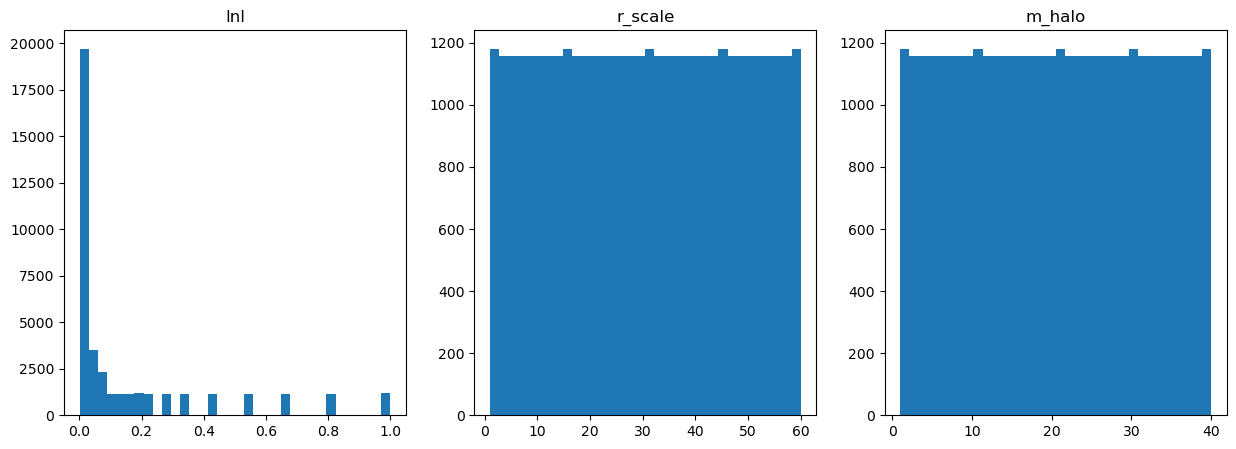

In [ ]:
# From a previously generated orbit grid search
if buildEnv:
    import glob
    orbit_dir = '/home/mbo2d/galStuff/data/orbit_gridsearch_5_test/'
    
    # First, load and combine all the log files
    log_files = glob.glob( os.path.join(orbit_dir, '*.log') )
    log_df = pd.DataFrame()
    for f in log_files:
        tmp_df = pd.read_csv(f)
        log_df = pd.concat([log_df, tmp_df], ignore_index=True)
    
    print( f'Logs: {log_df.shape}' )

    # Rename columns
    log_df.rename(columns={'rscale':'r_scale', 'mhalo':'m_halo'}, inplace=True)

    # Print ranges of lnl, r_scale, and m_halo
    print( f"lnl: {log_df['lnl'].min()} - {log_df['lnl'].max()}")
    print( f"r_scale: {log_df['r_scale'].min()} - {log_df['r_scale'].max()}")
    print( f"m_halo: {log_df['m_halo'].min()} - {log_df['m_halo'].max()}")

    # Do histogram showing where lnl, r_scale, and m_halo are
    fig, axs = plt.subplots(1, 3, figsize=(15,5))
    n_bins = 34
    # scale x axis to log
    axs[0].hist( log_df['lnl'], bins=n_bins )
    axs[0].set_title('lnl')

    axs[1].hist( log_df['r_scale'], bins=n_bins )
    axs[1].set_title('r_scale')

    axs[2].hist( log_df['m_halo'], bins=n_bins )
    axs[2].set_title('m_halo')
    

In [12]:
class simple_wrapper:

    def __init__ (self, tng_target):
        self.tng_target = tng_target
    
    def score_orbit_loc( self, orbit_loc ):
        # Load compressed numpy array
        orbit = np.load( orbit_loc )['arr_0']
        return self.score_func( orbit )
    
    def score_func( self, orbit ):
        return score_function_orbit_similarity_over_time( orbit, self.tng_target )

if buildEnv:

    simple_wrapper_1 = simple_wrapper( tng_target_1 )
    wr_score = simple_wrapper_1.score_func

    # Test if scoring orbit function works
    print("Scoring Orbits")
    for label, orbit_info in tng_target_1['test_orbits'].items():
        orbit = orbit_info['orbit']
        new_score = wr_score( orbit )
        print( f"Score for {label}: {new_score:.2f}")
    
    # Test if loading orbit file and scoring works
    n = 5
    print("Scoring Orbits from File")
    n_samples = log_df.sample(n)['orbit_loc'].values
    wr_load_score = simple_wrapper_1.score_orbit_loc    
    for s_loc in n_samples:
        print( f"{wr_load_score( s_loc ):.2f} - {s_loc}" )

    # Test if parallel queue manager works
    qm1 = qm.Queue_Manager( wr_load_score )
    print( "Queue Manger Work Mode: ", qm1.mode )
    print( "Processers Available: ", qm1.cpu_count )

    # Give to manager to process locations
    print("Testing Queue Manager")
    orbit_scores = qm1.evaluate_tasks( n_samples )
    print( "Scores: ", orbit_scores )

    print( "DONE!")

    

Scoring Orbits
Score for Default: 4.07
Score for Hand Found: 0.09
Score for Off Time: 4.36
Scoring Orbits from File


NameError: name 'log_df' is not defined

# View Gridsearch results

I performed a gridsearch of 3 variables a while back.  This was to load those and perform the score function on them

In [ ]:
if buildEnv and False:

    # Now let's pass all the locations to the queue manager
    orbit_locs = log_df['orbit_loc'].values
    orbit_locs = log_df.sample(10)['orbit_loc'].values  # override for testing purposes

    # Evaluate
    orbit_scores = qm1.evaluate_tasks( orbit_locs )

    # Save scores back in log_df
    # log_df['score'] = orbit_scores

    # Save log_df
    # log_df.to_csv( 'target_1_scores.cv', index=False )

    print( "DONE!")

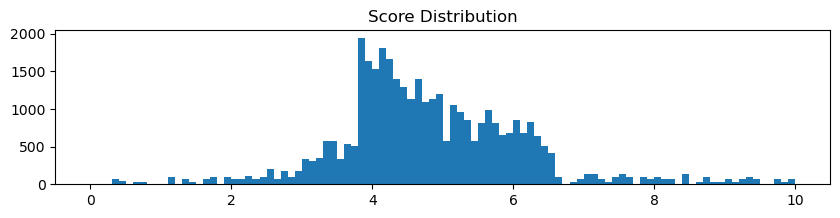

In [28]:
if buildEnv:
    gridsearch_df_loc = 'target_1_scores.csv'
    gs_df = pd.read_csv( gridsearch_df_loc )

    # set the bin range

    # create histogram of 'scores' column
    plt.hist( gs_df['score'], bins=100, range=(0,10) )
    plt.title("Score Distribution")

    # Set y axis to log scale
    # plt.yscale('log')

    # set figure size
    plt.gcf().set_size_inches(10, 2)

In [5]:
raise Exception("End of Script")

Exception: End of Script

In [ ]:
if buildEnv:
    

In [ ]:
class orbit_generator_class:

    def __init__(self, p_id, x_dict, save_dir = None, save_orbit = False):

        LOGGER.info("Setting up Orbit Generator...")
        self.p_id = p_id

        # Get MPI rank of myself
        rank = MPI.COMM_WORLD.Get_rank()

        # Save x_dict to keep input names for later function call
        if x_dict is not None:
            self.x_dict = x_dict
        else:
            LOGGER.error("x_dict cannot be None")
            raise ValueError("x_dict cannot be None")
        
        # If save_orbit is True, ensure there's a save dir
        if save_orbit and save_dir is None:
            LOGGER.error("save_dir must be set if save_orbit is True")
            raise ValueError("save_dir must be set if save_orbit is True")

        # If saving files, ensure the directory exists
        self.save_dir = None
        self.c = 0
        if save_dir is not None:
            self.save_dir = save_dir

            # create dir if needed
            if not os.path.exists( self.save_dir ):
                os.makedirs( self.save_dir )

            # Creat a log file that should be unique to me
            self.log_file = os.path.join( self.save_dir, f'{rank}.log' )

            # Create generic zip orbit path for later use
            self.orbit_loc = os.path.join( self.save_dir, f'{rank}_orbit_%d_%d.npz' )

            self.save_orbit = save_orbit

        # Create dataframe to hold info
        self.log_df = pd.DataFrame()

        # Setup default variables
        self.t_row, self.t_df, self.path = get_tng_target_orbit( self.p_id )

        # Create SPAM arrays for the target
        # print("Past Snap: ", self.path['before_closest_approach_snap'])
        self.tng_ar_1 = standardize_tng_parameters_v1( self.t_row )
        self.tng_ar_2 = standardize_tng_parameters_v2( self.t_df, self.t_row['snap'], self.path['before_closest_approach_snap'] )

        self.spam_ar_1 = convert_units_tng_to_spam( self.tng_ar_1 )
        self.spam_ar_2 = convert_units_tng_to_spam( self.tng_ar_2 )

        # print( f"SPAM AR 1: {self.spam_ar_1}")
        # print( f"SPAM AR 2: {self.spam_ar_2}")

    def create_orbit(self, in_setup_ar = None, in_setup_dict = None):

        if in_setup_dict is None and in_setup_ar is None:
            LOGGER.error("in_setup_dict or in_setup_ar must be set")
            raise ValueError("in_setup_dict or in_setup_ar must be set")

        if in_setup_dict is None:
            in_setup_dict = {}
            for i, x in enumerate(self.x_dict):
                in_setup_dict[x] = in_setup_ar[i]

        spam_orbit = spam_orbit_wrapper_squared( self.spam_ar_2, spam_setup_var=in_setup_dict, current_time=self.t_row['times_su'] )
        return spam_orbit

    def create_orbit_log_wrapper(self, in_setup_ar):

        # Loop through x_range and save name to in_ar variables
        in_setup_dict = {}
        for i, x in enumerate(self.x_dict):
            in_setup_dict[x] = in_setup_ar[i]

        LOGGER.debug("Running SPAM Simulation... %s", str(in_setup_dict))
        # spam_orbit_1 = spam_orbit_wrapper_squared( self.spam_ar_1, spam_setup_var=in_var, current_time=self.t_row['times_su'] )
        # LOGGER.debug( f"SPAM Orbit Shape: {spam_orbit_1.shape}" )
        spam_orbit_2 = spam_orbit_wrapper_squared( self.spam_ar_2, spam_setup_var=in_setup_dict, current_time=self.t_row['times_su'] )
        LOGGER.debug( f"SPAM Orbit Shape: {spam_orbit_2.shape}" )

        # Copy in_var and add keys and values to it
        in_var['p_id'] = self.p_id
        # in_var['orbit_n_1'] = spam_orbit_1.shape[0]
        in_var['orbit_n_2'] = spam_orbit_2.shape[0]
        in_var['c'] = self.c

        # Save orbit to a file
        if self.save_dir is not None:
            # tmp_save_loc_1 = self.orbit_loc % (self.c, 0)
            tmp_save_loc_2 = self.orbit_loc % (self.c, 1)
            
            # in_var['orbit_loc_1'] = tmp_save_loc_1
            in_var['orbit_loc_2'] = tmp_save_loc_2

            # np.savez( tmp_save_loc_1, spam_orbit_1 )
            np.savez( tmp_save_loc_2, spam_orbit_2 )

            LOGGER.debug( f"Saved Orbit to: {tmp_save_loc_1}" )

        # Add dict to dataframe
        self.log_df = pd.concat([self.log_df, pd.DataFrame([in_var])], ignore_index=True)

        # Save the dataframe
        if self.save_dir is not None: self.log_df.to_csv( self.log_file, index=False )
        
        self.c += 1 

        return spam_orbit_2
    

    def create_score_log_wrapper(self, in_setup_ar = None, in_setup_dict = None):

        if in_setup_dict is None and in_setup_ar is None:
            LOGGER.error("in_setup_dict or in_setup_ar must be set")
            raise ValueError("in_setup_dict or in_setup_ar must be set")
        
        if in_setup_dict is None:
            in_setup_dict = {}
            for i, x in enumerate(self.x_dict):
                in_setup_dict[x] = in_setup_ar[i]
        
        LOGGER.debug("Running SPAM Simulation... %s", str(in_setup_dict))
        spam_orbit = spam_orbit_wrapper_squared( self.spam_ar_2, spam_setup_var=in_setup_dict, current_time=self.t_row['times_su'] )
        LOGGER.debug( f"SPAM Orbit Shape: {spam_orbit.shape}" )
        
        # Get score for spam_orbit
        score = orbit_weighted_score_function( self.path, spam_orbit )

        # Add info to log
        log_dict = in_setup_dict.copy()
        log_dict['p_id'] = self.p_id
        log_dict['score'] = score
        log_dict['c'] = self.c
        log_dict['orbit_n'] = spam_orbit.shape[0]

        # Save orbit to a file
        if self.save_dir is not None and self.save_orbit:
            tmp_save_loc = self.orbit_loc % (self.c, 1)
            log_dict['orbit_loc'] = tmp_save_loc
            np.savez( tmp_save_loc, spam_orbit )
            LOGGER.debug( f"Saved Orbit to: {tmp_save_loc}" )
        else:
            LOGGER.debug("Not saving orbit")
        # Add dict to dataframe
        self.log_df = pd.concat([self.log_df, pd.DataFrame([log_dict])], ignore_index=True)

        # Save the dataframe
        if self.save_dir is not None: self.log_df.to_csv( self.log_file, index=False )

        # increment counter
        self.c += 1

        return score

if buildEnv:
    
    # Set up grid search variables and bounds
    test_dict = {
        'lnl': {'bounds':[0.001, 1], 'prior': 'log-uniform'},
        'r_scale': {'bounds':[1, 60], 'prior': 'uniform'},
        'mhalo': {'bounds':[1, 40], 'prior': 'uniform'}
    }

    default = [0.1, 10.0, 5.8]
    hand = [0.007, 20.0, 5.8]

    LOGGER.setLevel(logging.INFO)

    # Create a generator
    gen = orbit_generator_class( p1, test_dict )

    tmp_orbit_d = gen.create_orbit( default )
    tmp_score_d = gen.create_score_log_wrapper( default )

    tmp_orbit_h = gen.create_orbit( hand )
    tmp_score_h = gen.create_score_log_wrapper( hand )

    # plot these paths
    plot_list = path1['plot_list'].copy()
    plot_labels = path1['plot_labels'].copy()
    plot_annotations = path1['annotate_data'].copy()

    plot_list.append( tmp_1 )
    plot_labels.append( 'Default - %f' % tmp_score_d )
    plot_annotations = add_annotate_times( plot_annotations, tmp_1, path['times_su'] )

    plot_list.append( tmp_2 )
    plot_labels.append( 'Hand - %f' % tmp_score_h )
    plot_annotations = add_annotate_times( plot_annotations, tmp_2, path['times_su'] )

    xy_histogram( \
        pts1, \
        plot_list, plot_labels, \
        show_labels = True, std_dev = 5,
        annotate_data= plot_annotations,
        title = 'Orbit Generator Test',
        figsize=(12,12),
    )


In [ ]:

def gen_orbit_gridsearch( args, x_dict = None ):

    LOGGER.info("Running Orbit Gridsearch Test...")

    # Get important parameters
    t_id = args.target_id
    time_in_sec = int(args.input)
    output_dir = args.output

    # Set up grid search variables and bounds
    if x_dict is None:
        x_dict = {
            'lnl': {'bounds':[0.001, 1], 'prior': 'log-uniform'},
            'rscale': {'bounds':[1, 60], 'prior': 'uniform'},
            'm_halo': {'bounds':[1, 40], 'prior': 'uniform'}
        }

    # prep black box
    gen = orbit_generator_class( t_id, x_dict=x_dict, save_dir = output_dir, save_orbit=True )

    # Setup MPI for parallel processing
    comm = MPI.COMM_WORLD
    rank = comm.Get_rank()
    size = comm.Get_size()

    # Setup workers to be on standby
    if rank != 0:
        worker = om.Optimization_Manager( gen.create_score_log_wrapper, x_dict )
    
    # Setup master to run the optimization
    elif rank == 0:
        manager = om.Optimization_Manager( gen.create_score_log_wrapper, x_dict )
        results = manager.initial_exploration( time_cutoff_sec= time_in_sec )

        print("FINAL results: ", len(results)) 
        print(results)   

        del manager

    # End the MPI process

# Already completed
if buildEnv and True:
    cmdLine = 'python3 /home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/convert_tng_to_spam.py'
    cmdLine += ' --function gen_orbit_gridsearch'
    cmdLine += ' -id 62000000190717'
    cmdLine += ' --input 10'
    cmdLine += ' --output /home/mbo2d/galStuff/data/orbit_gridsearch_5_test/'

    # Add mpiexec to the front of the command

    print( f"mpiexec -n 4 {cmdLine}" )
    tmp_parser = gu.ArgHandler()
    build_arg = tmp_parser.parse_args_from_string(cmdLine)
    test_x = {
        'lnl': {'bounds':[0.001, 1], 'prior': 'log-uniform'},
    }

    LOGGER.setLevel( logging.INFO )

    # gen_orbit_gridsearch( build_arg, x_dict = test_x )

    # Save cmdline in a script 
    test_script_loc = '/home/mbo2d/galStuff/cluster/batch_files/test_gridsearch.sh'
    with open(test_script_loc, 'w') as f:
        f.write( cmdLine )

if script_args.function == 'gen_orbit_gridsearch':
    gen_orbit_gridsearch( script_args, )

In [42]:
import glob
# Let's load all the orbits and verify they're behaving as expected
if buildEnv:
    orbit_dir = '/home/mbo2d/galStuff/data/orbit_gridsearch_5_test/'
    
    # First, load and combine all the log files
    log_files = glob.glob( os.path.join(orbit_dir, '*.log') )
    log_df = pd.DataFrame()
    for f in log_files:
        tmp_df = pd.read_csv(f)
        log_df = pd.concat([log_df, tmp_df], ignore_index=True)
    
    print( f'Logs: {log_df.shape}' )

    # Print ranges of lnl, r_scale, and mhalo
    print( f"lnl: {log_df['lnl'].min()} - {log_df['lnl'].max()}")
    print( f"r_scale: {log_df['rscale'].min()} - {log_df['rscale'].max()}")
    print( f"m_halo: {log_df['m_halo'].min()} - {log_df['m_halo'].max()}")
    
    # Second load all the orbits
    orbit_files = glob.glob( os.path.join(orbit_dir, '*.npz') )
    orbit_list = []
    for f in orbit_files:
        tmp_orbit = np.load(f)
        orbit_list.append( tmp_orbit['arr_0'] )
    
    print( 'N Orbits %d' % len(orbit_list) )

    # Load them all and plot them
    
    plot_list = path1['plot_list'].copy()
    plot_labels = path1['plot_labels'].copy()
    plot_annotations = path1['annotate_data'].copy()

    for i, orbit in enumerate(orbit_list):
        plot_list.append( orbit )
        plot_labels.append( f'Orbit {i}' )
        plot_annotations = add_annotate_times( plot_annotations, orbit, path['times_su'] )
    
    xy_histogram( \
        pts1, \
        plot_list, plot_labels, \
        show_labels = True, std_dev = 5,
        annotate_data= plot_annotations,
        title = 'Orbit Generator Test',
        figsize=(12,12),
    )


Logs: (39428, 8)
lnl: 0.001 - 1.0
r_scale: 1.0 - 60.0
mhalo: 1.0 - 40.0


KeyboardInterrupt: 

In [ ]:
if buildEnv and False:

    # okay, create a bunch of scripts to send to my cluster
    run_dir = '/home/mbo2d/galStuff/cluster/batch_files/'
    baseCMD = 'python3 /home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/convert_tng_to_spam.py'
    baseCMD += ' --function gen_orbit_gridsearch'
    baseCMD += ' -id %s'
    baseCMD += ' --output /home/mbo2d/galStuff/data/orbit_gridsearch/%s/'
    baseCMD += ' --input %d'

    # Loop through all rows that have moi_4_rating >= 3
    good_targets = tng_targets[tng_targets['moi_4_rating'] >= 4]

    # sort so highest is first
    good_targets = good_targets.sort_values(by='moi_4_rating', ascending=False)

    # Create batch file
    file_name = 'gridsearch_cmds_4.sh'
    f = open(f'{run_dir}/{file_name}', 'w')

    # Create test batch file too
    test_file_name = 'gridsearch_cmds_4_test.sh'
    f_test = open(f'{run_dir}/{test_file_name}', 'w')

    # exe_time 
    n_hr = 0.25
    exe_time = n_hr * 60*60 # an hour

    for idx, row in good_targets.iterrows():
        t_id = row['p_SubhaloIDRaw']

        cmdLine = baseCMD % (t_id, t_id, exe_time)
        build_arg = PARSER.parse_args(cmdLine.split()[2:]) # Skip the first two arguments
        
        # Write to file
        f.write( cmdLine + '\n')

        # if matches p1 or p2, save as test
        if t_id == p1 or t_id == p2:
            print("Test: ", t_id)
            testCMD = cmdLine + ' --log-level DEBUG'
            f_test.write( testCMD + '\n')
    
    f.close()
    f_test.close()

    # print size of good_targets
    print( f"Good Targets: {len(good_targets)}" )

In [ ]:
if buildEnv:
    test_orbit_dir = '/home/mbo2d/galStuff/data/orbit_gridsearch_5_test/'

    # Get all files in the directory
    all_files = os.listdir( test_orbit_dir )

    # Loop through log files and load them
    all_dfs = []
    for f in all_files:
        if f.endswith('.log'):
            all_dfs.append( pd.read_csv( os.path.join( test_orbit_dir, f ) ) )

    # Concatenate all dataframes
    log_df = pd.concat( all_dfs, ignore_index=True )

    # print length
    print( f"Total Orbits: {len(log_df)}" )

    # Print head
    print( log_df.head() )

    # Add cutoff for orbits that are too long
    # cutoff = 4000
    # log_df = log_df[log_df['orbit_n_1'] < cutoff]

    # # Remove those above 
    n_values_1 = log_df['orbit_n_1'].values
    n_values_2 = log_df['orbit_n_2'].values

    # Get unique values in each 
    unique_n_1 = np.unique( n_values_1 )
    unique_n_2 = np.unique( n_values_2 )

    print( f"Unique N 1: {unique_n_1}" )
    print( f"Unique N 2: {unique_n_2}" )

    # Let's create two subplots on top of each other
    fig, axs = plt.subplots(2, 1, figsize=(12, 12))
    
    # Plot the histogram of the orbit_n values
    axs[0].hist( n_values_1, bins=100, color='b', alpha=0.7 )
    axs[0].set_title("Orbit N Values - TNG_2_SPAM v1")

    axs[1].hist( n_values_2, bins=100, color='r', alpha=0.7 )
    axs[1].set_title("Orbit N Values - TNG_2_SPAM v2")

    # # Grab the rows with the highest and lowest orbit_n values
    # print( log_df[log_df['orbit_n'] == np.max(log_df['orbit_n'].values)] )
    # print( log_df[log_df['orbit_n'] == np.min(log_df['orbit_n'].values)] )

    # # lOG SCALE
    plt.show()

In [ ]:
if buildEnv:
    # Those number DO NOT look right, let's check the input values and see if they are correct
    lnl_values = log_df['lnl'].unique()
    rscale_values = log_df['rscale'].unique()
    mhalo_values = log_df['m_halo'].unique()

    # Create 3 subplots for each and do a histogram
    fig, axs = plt.subplots(3, 1, figsize=(12, 12))
    bins = 20

    axs[0].hist( lnl_values, bins=bins, color='b', alpha=0.7 )
    axs[0].set_title("lnl Values")

    axs[1].hist( rscale_values, bins=bins, color='r', alpha=0.7 )
    axs[1].set_title("rscale Values")

    axs[2].hist( mhalo_values, bins=bins, color='g', alpha=0.7 )
    axs[2].set_title("m_halo Values")


    # So there is a good spread of the input values... but why are the orbit_n only 3 different values?

In [ ]:
# There are too many orbits to load in at the same time.  Let's just load them when we need them later. 
if buildEnv and False:
    import time

    # Load Pts
    start = time.time()
    c = 0
    n = log_df.shape[0]
    # n = 1000

    spam_orbits = {}

    for idx, row in log_df.iterrows():
        loc1 = row['orbit_loc_1']
        loc2 = row['orbit_loc_2']

        spam_orbits[idx] = {}
        spam_orbits[idx][0] = np.load( loc1 )['arr_0']
        spam_orbits[idx][1] = np.load( loc2 )['arr_0']

        # Print shape
        # print( f"Loaded Orbit: {idx} - Shape: {spam_orbits[idx].shape}" )

        if c >= n:
            break
        c +=1 

        print( f"Loaded {c} / {n} orbits", end='\r')

    end = time.time()

    print( f"Time to load {n} sets of points: {end-start} seconds" )

In [ ]:

def compute_weighted_error( path_tng, spam_orbit, dev_print = False):
    """
    Computes the weighted error between the true path and the simulated path.

    Parameters:
    - path_tng: (dictionary) contains the true path, spline function, and weight function for the tng orbit.
    - spam_orbit: (numpy array Nx7), spam simulated path.

    
    Returns:
    - E: float, total weighted error.
    """

    # length and times of spam orbit
    n_spam = len(spam_orbit)
    times = spam_orbit[:,-1]
    dt = abs((times[-1] - times[0]) / (n_spam - 1))

    # If length of times is under n_min, find dt and extrapolate t to n_min
    if len(times) < n_min:

        # Calc how many more steps we need to take to reach n_min
        n_more = n_min - len(times)

        # Extratolape new times  before the orbit starts
        new_times = np.linspace( times[0]-n_more*dt, times[0]-dt, n_more)
        added_times = np.concatenate( (new_times, times, ) )

        if dev_print:
            print( f"Times: {times.shape}")
            print( f"New Times: {new_times.shape}")
            print(f"Added Times: {added_times.shape}")
            #print first 10 values each
            print( times[:10])
            print( added_times[:10])

            # Print last 10 values
            print( times[-10:])
            print( added_times[-10:])
        
        times = added_times
    
    else:
        n_more = 0

    # Create new tng_path from spline func using spam times
    tng_orbit = np.array([ [spline(t) for spline in path_tng['s_fixed_su_cubic_nat_func']] for t in times ])
    n_tng = len(tng_orbit)

    if dev_print: print( f"Path TNG: {tng_orbit.shape}")

    # Initialize errors and weights
    errors = np.zeros(n_tng)
    weights = np.zeros(n_tng)

    # Compute errors
    for i in range(n_tng):
        if i < n_more:
            # Directly compare positions for same time step
            e = np.linalg.norm(spam_orbit[0,0:3] - tng_orbit[i,0:3]) ** 2
        else:
            # Use first simulated position
            spam_idx = i - n_more
            e = np.linalg.norm(spam_orbit[spam_idx,0:3] - tng_orbit[i,0:3]) ** 2
        errors[i] = e

    if dev_print: print( f"Errors: {errors.shape}")

    # Compute weights
    weights[:-n_min] = 1  # Full weight before minimum length
    weights[-n_min:] = np.linspace(1, 0, n_min)

    # Compute weighted error
    E = np.sum(weights * errors)
    total_weight = np.sum(weights)
    E_normalized = E / total_weight

    return E_normalized

class score_wrapper_class:

    def __init__( self, pid, ):
        self.pid = pid
        self.t_row, self.t_df, self.t_ar, self.path = get_tng_target_orbit( self.pid )

    def score_wrapper( self, spam_orbit ):
        return compute_weighted_error( self.path, spam_orbit )


if buildEnv:

    # Get idx of orbit with shortest length
    idx = np.argmin([ len(spam_orbits[i]) for i in spam_orbits.keys() ])

    # get idx of longest orbit
    idx_long = np.argmax([ len(spam_orbits[i]) for i in spam_orbits.keys() ])
    
    # Print index values and lengths they represent
    print(f"Shortest Orbit: {idx} - Length: {len(spam_orbits[idx])}")
    print(f"Longest Orbit: {idx_long} - Length: {len(spam_orbits[idx_long])}")
    
    hand_E = compute_weighted_error(path1, hand_spam_orbit, dev_print=False )
    short_E = compute_weighted_error(path1, spam_orbits[idx], dev_print=True)
    long_E = compute_weighted_error(path1, spam_orbits[idx_long], dev_print=False )

    print(f"Error")
    print(f"Best by Hand Error: {hand_E:.10f}")
    print(f"Longest Error: {long_E:.10f}")
    print(f"Shortest error: {short_E:.10f}")

    print("\nTesting wrapper class")
    score_class = score_wrapper_class( p1 )
    print( f"Best Hand Score: {score_class.score_wrapper( hand_spam_orbit )}")
    print( f"Longest Score: {score_class.score_wrapper( spam_orbits[idx_long] )}")
    print( f"Shortest Score: {score_class.score_wrapper( spam_orbits[idx] )}")

    

In [ ]:


if buildEnv:

    # Create a test input
    test_input = {
        'path_tng': path1,
        'spam_orbit': hand_spam_orbit,
    }

    # Run the error wrapper
    test_error = error_wrapper( test_input )
    print( f"Test Error: {test_error}" )

In [ ]:
if buildEnv:
    # Let's iterate over the spam_orbits and compute the error
    n = len( spam_orbits )
    for i in spam_orbits.keys():
        print( i, n, end='\r')
        E = compute_weighted_error(path1, spam_orbits[i], dev_print=False )
        log_df.loc[i, 'error'] = E

    print( log_df.head() )



In [ ]:
if buildEnv:

    # save log 
    log_df.to_csv( 'test_log_df.csv', index=False )

In [ ]:
if buildEnv:
    log_df = pd.read_csv( 'test_log_df.csv' )
    print( log_df.head() )

In [ ]:
def interactive_3d_scatter_heat_plot( in_inputs, in_scores, title = '3D Heat Map of Input Scores',\
                                      log_values = [False, False, False, False],   #  [x, y, z, score]
                                    ):


    # Copy inputs and scores
    inputs = np.copy( in_inputs )
    scores = np.copy( in_scores )

    # Normalize scores for visualization
    normalized_scores = (scores - scores.min()) / (scores.max() - scores.min())

    # If any log_values are true, apply log scaling.  Keep true values for axis plot
    for i, scale in enumerate(log_values):

        if scale:
            if i == 3:
                scores = np.log1p(scores)
            else:
                inputs[:,i] = np.log1p(inputs[:,i])



    # Create a 3D scatter plot
    fig = px.scatter_3d(
        x=inputs[:, 0], 
        y=inputs[:, 1], 
        z=inputs[:, 2],
        color=normalized_scores,  # Heat map based on scores
        size=1/(scores + 1e-6),   # Larger size for smaller scores
        color_continuous_scale='Turbo',  # Rainbow-like color scale
        title="3D Heat Map of Input Scores"
    )
    

    # Adjust layout
    fig.update_layout(
        scene=dict(
            xaxis_title="Input 1",
            yaxis_title="Input 2",
            zaxis_title="Input 3"
        )
    )

    # Show the interactive plot
    fig.show()


if buildEnv:

    inputs = log_df[['lnl', 'rscale', 'mhalo']].values
    scores = log_df['error'].values

    # Visualize the input points and scores
    interactive_3d_scatter_heat_plot(inputs, scores, log_values=[False, True, True, True])


In [ ]:
def get_top_results( t_id, n_results = 5, dev_print = False ):
        
        output = '/home/mbo2d/galStuff/data/orbit_gridsearch/%s_2.csv' % t_id
        grid_search_df = pd.read_csv(output)

        # rename rscale to r_scale
        grid_search_df = grid_search_df.rename(columns={'rscale': 'r_scale'})
        grid_search_df = grid_search_df.rename(columns={'mhalo': 'm_halo'})

        # Filter out rows that resulted in short paths
        grid_search_df = grid_search_df[ grid_search_df['lnl'] <= 0.1 ]
        grid_search_df = grid_search_df[ grid_search_df['m_halo'] != 1.0 ]

        if dev_print:
            print( f"Results: {grid_search_df.shape}" )
            print( f"Best Score:", grid_search_df['final_value'].min() )
            print( grid_search_df.head() )
            

        # Grab the lowest n_results final_value rows
        top_results = grid_search_df.nsmallest(n_results, 'final_value')

        return top_results
    

if buildEnv and False:
    
        # Get grid_search results
        t_id = 62000000190717

        top_results = get_top_results( t_id, 3, True )

        # Print quantity of unique final values
        print("\nTOP RESULTS")
        print( top_results )

        in_var = []
        in_var.append({ 'label':"SPAM Default" })

        in_var.append( {
                'lnl': 0.007, 'r_scale': 20, 'mhalo': 5.8,
                'label': 'Discovered by Hand', 
        })

        c = 0
        for idx, row in top_results.iterrows():
            in_var.append( {
                'lnl': row['lnl'], 'r_scale': row['r_scale'], 'mhalo': row['mhalo'],
                'label': f'Top Grid Result: {c}', 'score': row['final_value']
            })
            c += 1

        plot_tng_spam_orbits( t_row, t_df, pts_raw, in_var, True, title = 'Top Orbit Gridsearch Results' )
                
        # End the MPI process

In [ ]:
if buildEnv:
    # Sort log_df by error
    log_df = log_df.sort_values(by='error', ascending=True)
    
    # Get first 20
    top_results = log_df.head(20)
    print( top_results )

In [ ]:
def plot_tng_spam_pts( t_row, t_df, pts_raw, spam_var, dev_print = False, title = 'TNG SPAM Comparison', n_spam_pts = 2000 ):

    # Get TNG dynamics info 
    tng_ar = standardize_tng_parameters_v1( t_row )
    spam_ar = convert_units_tng_to_spam( tng_ar )

    # Extract path
    p_path, s_path = get_moving_path( t_row, t_df )

    # Save in convenient format
    path = {}
    path['p_moving'] = p_path
    path['s_moving'] = s_path
    path['snaps'] = np.stack( t_df['snap'].values )
    path['times'] = np.stack( t_df['time_gyr'].values )

    path['s_fixed'] = convert_to_fixed_frame( p_path, s_path )
    pts_tu = tf.apply_transformation( t_row['orbital_frame_pos_transform'], pts_raw )
    pts_tu[:,0:3] = pts_tu[:,0:3] - t_row['p_SubhaloPos_orbital_frame']
    
    # convert tng pts to spam units
    pts_su = np.copy( pts_tu )
    pts_su[:,0:3] = convert_distance_tng_to_spam( pts_tu[:,0:3] )
    pts_su[:,3:6] = convert_velocity_tng_to_spam( pts_tu[:,3:6] )

    # Convert the paths to SPAM units
    path['times_su'] = convert_time_tng_to_spam( path['times'] )
    path['p_moving_su'] = np.copy( path['p_moving'] )
    path['p_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['p_moving'][:,0:3] )
    path['p_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['p_moving'][:,3:6] )
    path['s_moving_su'] = np.copy( path['s_moving'] )
    path['s_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['s_moving'][:,0:3] )
    path['s_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_moving'][:,3:6] )
    path['s_fixed_su'] = np.copy( path['s_fixed'] )
    path['s_fixed_su'][:,0:3] = convert_distance_tng_to_spam( path['s_fixed'][:,0:3] )
    path['s_fixed_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_fixed'][:,3:6] )
    
    # Create Splines for plotting
    path['s_fixed_su_cubic_herm_func'] = interpolate_path_with_velocities(path['times_su'], path['s_fixed_su'])
    path['s_fixed_su_cubic_nat_func'] = interpolate_path_natural_cubic(path['times_su'], path['s_fixed_su'])
    path['s_times_test'] = np.linspace( path['times_su'][0], path['times_su'][-1], 1000 )
    path['s_fixed_su_cubic_herm_test'] = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_herm_func']] for t in path['s_times_test'] ])

    # Add plots and labels
    plot_list = [path['s_fixed_su_cubic_herm_test']]
    plot_labels = ['Hermite', ]

    # Create list of tuples from secondary fixed path and snap data
    annotate_data = [(path['s_fixed_su'][i, 0:2], f"{path['snaps'][i]} - {path['times'][i]:.2f} Gyr") for i in range(len(path['snaps']))]
    annotate_data.append( ([0,0], 'Primary') ) # primary galaxy center

    # Create SPAM orbits

    # Get lnl, r_scale, mhalo as dict
    x_set = { k: spam_var[k] for k in ['lnl', 'r_scale', 'mhalo'] }

    if dev_print:
        print(f"Running SPAM Simulation with: {x_set}")

    
    # Use input to prep SPAM simulation
    sim.set_simulation_variables( **x_set )

    r_scale = 2
    spam_ar[8:9] = r_scale  * spam_ar[8:9]

    # Run SPAM simulation
    spam_orbit = spam_orbit_wrapper_squared( spam_ar, current_time=t_row['times_su'], dev_print=dev_print )


    if dev_print:
        print( f"SPAM Orbit Shape: {spam_orbit.shape}" )
    
    if score is not None:
        score2 = score_run_v1( spam_orbit, path['s_fixed_su_cubic_herm_func'], dev_print=False )

        print(f"Score: {score} - {score2}")
    
    # Now run 
    ipts, fpts = sim.basic_run_wrapper( spam_ar, npts1 = n_spam_pts, npts2 = n_spam_pts, heat1 = 0.1, heat2 = 0.1,)
    
    # append to plot lists
    plot_list.append( spam_orbit )
    plot_labels.append( 'SPAM_run' )
    annotate_data = add_annotate_times( annotate_data, spam_orbit, path['times_su'] )

    # Create a side by side subplot of size 12x12
    fig, axs = plt.subplots(1, 2, figsize=(24, 12))

    # set overall title
    fig.suptitle(title, fontsize=16)

    # tighter layout
    plt.tight_layout()

    xy_histogram( \
        pts_su, \
        plot_list, plot_labels, \
        show_labels = True, std_dev = 3,
        annotate_data= annotate_data,
        title = 'TNG Pts',
        ext_ax = axs[0],
        bins = 200,
    )

    xy_histogram( \
        fpts, \
        plot_list, plot_labels, \
        show_labels = True, std_dev = 3,
        annotate_data= annotate_data,
        title = 'SPAM Pts',
        ext_ax = axs[1],
        bins = 200
    )

    plt.show()

if buildEnv and True:

    # x_set = {
    #     'lnl': 0.007, 'r_scale': 20, 'm_halo': 5.8,
    #     'label': 'Top_Grid_Result_0'
    # }

    plot_tng_spam_pts( t_row, t_df, pts_raw, top_grid_result.iloc[0], True )

In [ ]:

if buildEnv and True:

    # print( good_targets.head )
    # plot_tng_spam_pts( t_row, t_df, pts_raw, top_grid_result, True )

    c = 0
    for i, row in good_targets.iterrows():


        tmp_id = row['p_SubhaloIDRaw']


        print( c, i, tmp_id )

        #$ Verify particles are in the right place
        try:
            tmp_pts = load_pts_data( tmp_id, dev_print = False )
        except:
            print( f"Error: {tmp_id}" )
            continue

        top_result = get_top_results( row['p_SubhaloIDRaw'], 1, True )

        tmp_row, tmp_df = extractTargetData( tmp_id, tng_targets, dev_print = False )        

        plot_tng_spam_pts( tmp_row, tmp_df, tmp_pts, top_result.iloc[0], True )

        c +=1 
        if c > 10: break